# Revamped Advanced Modeling Notebook for STN_0003

This notebook is a cleaned, step-by-step rebuild of the previous modeling attempt. It keeps the original intent — forecasting station demand for **STN_0003** — but restructures the workflow around the actual schema and modeling constraints observed in `incWeatherFeatures_df`.

## Notebook plan

1. Load the silver rides data and the weather-enhanced feature table.
2. Validate schema, nulls, and feature usability.
3. Build a clean **station-level hourly series** for `STN_0003` from rides data.
4. Prepare a clean **multi-station weather-aware panel** from `incWeatherFeatures_df`.
5. Run **Modeling Path A: Prophet** for station-level time series forecasting.
6. Run **Modeling Path B: Spark ML baseline** for panel regression using weather and calendar features.
7. Compare outputs and record next-step recommendations.

## Main fixes versus the previous notebook

- Keeps `ts_hour` **out** of `VectorAssembler`; instead derives `hour_of_day`.
- Drops `community_id` because it is fully null in the profiled schema.
- Fills nulls in `temp`, `precip`, `lat`, `lon`, and `dist_km`.
- Avoids passing raw string columns into Spark ML unless explicitly encoded.
- Uses Prophet on a **single station series**, which is the correct grain for that model.
- Separates the **station forecasting path** from the **multi-station baseline path**.

## 1. Environment setup and data loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

plt.rcParams["figure.figsize"] = (12, 5)

spark = SparkSession.builder.appName("revamped_STN_0003_modeling").getOrCreate()
spark.conf.set("spark.sql.session.timeZone", "America/Toronto")

RIDES_PATH = "../../data/silver/rides/"
WEATHER_FEATURES_PATH = "../../data/weather/features_incWeather"

TARGET_STATION_ID = "STN_0003"

rides_df = spark.read.parquet(RIDES_PATH, unionByName=True)
incWeatherFeatures_df = spark.read.parquet(WEATHER_FEATURES_PATH)

print("rides_df rows:", rides_df.count())
print("incWeatherFeatures_df rows:", incWeatherFeatures_df.count())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/04 11:14:02 WARN Utils: Your hostname, users-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.249.142.177 instead (on interface en0)
26/04/04 11:14:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/04 11:14:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


rides_df rows: 39377433
incWeatherFeatures_df rows: 6179615


## 2. Quick inspection of `incWeatherFeatures_df`

In [2]:
incWeatherFeatures_df.printSchema()
incWeatherFeatures_df.show(5, truncate=False)
incWeatherFeatures_df.describe().show()

root
 |-- station_id: string (nullable = true)
 |-- ts_hour: timestamp (nullable = true)
 |-- demand_count: long (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- community_id: long (nullable = true)
 |-- temp: float (nullable = true)
 |-- precip: float (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- metro_proximity: string (nullable = true)
 |-- metro_name: string (nullable = true)
 |-- dist_km: double (nullable = true)
 |-- transit_proximity_tier: string (nullable = true)



+-----------------------------------------------------------+-------------------+------------+-----------+----------+----------+------------+-----+------+---------+----------+---------------+-------------+-------------------+--------------------------+
|station_id                                                 |ts_hour            |demand_count|day_of_week|is_weekend|is_holiday|community_id|temp |precip|lat      |lon       |metro_proximity|metro_name   |dist_km            |transit_proximity_tier    |
+-----------------------------------------------------------+-------------------+------------+-----------+----------+----------+------------+-----+------+---------+----------+---------------+-------------+-------------------+--------------------------+
|45.524790,-73.565450|calixa-lavallée / sherbrooke          |2024-06-24 16:00:00|9           |2          |0         |1         |NULL        |21.4 |0.0   |45.52479 |-73.56545 |High           |Sherbrooke   |0.7256533163973264 |Tier 2: Commuter

26/04/04 09:39:02 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+--------------------+-----------------+-----------------+-------------------+-------------------+------------+------------------+-------------------+-------------------+------------------+---------------+-----------------+--------------------+----------------------+
|summary|          station_id|     demand_count|      day_of_week|         is_weekend|         is_holiday|community_id|              temp|             precip|                lat|               lon|metro_proximity|       metro_name|             dist_km|transit_proximity_tier|
+-------+--------------------+-----------------+-----------------+-------------------+-------------------+------------+------------------+-------------------+-------------------+------------------+---------------+-----------------+--------------------+----------------------+
|  count|             6179615|          6179615|          6179615|            6179615|            6179615|           0|           6141286|            6141286|            61

In [3]:
# Null profile for the weather feature table
total_rows = incWeatherFeatures_df.count()

null_profile_exprs = [
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in incWeatherFeatures_df.columns
]

null_profile = incWeatherFeatures_df.select(*null_profile_exprs).toPandas().T.reset_index()
null_profile.columns = ["column_name", "null_count"]
null_profile["null_pct"] = (null_profile["null_count"] / total_rows * 100).round(2)
null_profile.sort_values(["null_pct", "null_count"], ascending=False)

,column_name,null_count,null_pct
6,community_id,6179615,100.00
7,temp,38329,0.62
8,precip,38329,0.62
9,lat,8019,0.13
10,lon,8019,0.13
13,dist_km,8019,0.13
0,station_id,0,0.00
1,ts_hour,0,0.00
2,demand_count,0,0.00
3,day_of_week,0,0.00


### Interpretation notes

Use the checks above to confirm the assumptions behind the modeling redesign:

- `community_id` is expected to be fully null and should be dropped.
- `temp` and `precip` are usable, but require null handling.
- `metro_proximity`, `metro_name`, and `transit_proximity_tier` are categorical strings and should not go directly into `VectorAssembler`.
- `ts_hour` is a proper timestamp and should be used for time filtering and feature derivation, not as a raw ML feature.

In [ ]:
# ============================================================
# 1. Schema / data validation checks for modeling assumptions
# ============================================================
from pyspark.sql import functions as F

print("\n=== Row count ===")
print(f"Total rows: {incWeatherFeatures_df.count():,}")

# Count nulls for key columns
null_summary = incWeatherFeatures_df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in [
        "community_id", "temp", "precip",
        "metro_proximity", "metro_name", "transit_proximity_tier",
        "ts_hour"
    ]
])

print("\n=== Null summary ===")
null_summary.show(truncate=False)

# Distinct/category sanity checks
print("\n=== Categorical column sample values ===")
for c in ["metro_proximity", "metro_name", "transit_proximity_tier"]:
    print(f"\nColumn: {c}")
    incWeatherFeatures_df.groupBy(c).count().orderBy(F.desc("count")).show(10, truncate=False)

# Timestamp validity check
print("\n=== ts_hour range ===")
incWeatherFeatures_df.select(
    F.min("ts_hour").alias("min_ts_hour"),
    F.max("ts_hour").alias("max_ts_hour")
).show(truncate=False)

# Weather completeness check
print("\n=== Weather completeness summary ===")
incWeatherFeatures_df.select(
    F.count("*").alias("total_rows"),
    F.count("temp").alias("temp_non_null"),
    F.count("precip").alias("precip_non_null"),
    F.round(F.count("temp") / F.count("*") * 100, 2).alias("temp_non_null_pct"),
    F.round(F.count("precip") / F.count("*") * 100, 2).alias("precip_non_null_pct")
).show(truncate=False)

=== Schema ===
root
 |-- station_id: string (nullable = true)
 |-- ts_hour: timestamp (nullable = true)
 |-- demand_count: long (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- community_id: long (nullable = true)
 |-- temp: float (nullable = true)
 |-- precip: float (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- metro_proximity: string (nullable = true)
 |-- metro_name: string (nullable = true)
 |-- dist_km: double (nullable = true)
 |-- transit_proximity_tier: string (nullable = true)


=== Row count ===
Total rows: 6,179,615

=== Null summary ===


+------------+-----+------+---------------+----------+----------------------+-------+
|community_id|temp |precip|metro_proximity|metro_name|transit_proximity_tier|ts_hour|
+------------+-----+------+---------------+----------+----------------------+-------+
|6179615     |38329|38329 |0              |0         |0                     |0      |
+------------+-----+------+---------------+----------+----------------------+-------+


=== Categorical column sample values ===

Column: metro_proximity


+---------------+-------+
|metro_proximity|count  |
+---------------+-------+
|High           |2546954|
|Low            |2008540|
|Very High      |1624121|
+---------------+-------+


Column: metro_name


+--------------------+------+
|metro_name          |count |
+--------------------+------+
|Mont-Royal          |432344|
|Laurier             |374289|
|Sherbrooke          |259774|
|Rosemont            |206411|
|Préfontaine         |204532|
|Place-des-Arts      |162434|
|Frontenac           |160254|
|Beaubien            |156419|
|D'Iberville         |149228|
|Square-Victoria-OACI|148670|
+--------------------+------+
only showing top 10 rows

Column: transit_proximity_tier
+--------------------------+-------+
|transit_proximity_tier    |count  |
+--------------------------+-------+
|Tier 2: Commuter Catchment|2546954|
|Tier 3: Transit Desert    |2008540|
|Tier 1: High Proximity    |1624121|
+--------------------------+-------+


=== ts_hour range ===
+-------------------+-------------------+
|min_ts_hour        |max_ts_hour        |
+-------------------+-------------------+
|2024-01-01 00:00:00|2026-01-31 23:00:00|
+-------------------+-------------------+


=== Weather completeness sum

In [5]:
# ============================================================
# 2. Interpretation checks as explicit assertions
# ============================================================

total_rows = incWeatherFeatures_df.count()

community_id_non_null = incWeatherFeatures_df.filter(F.col("community_id").isNotNull()).count()
temp_non_null = incWeatherFeatures_df.filter(F.col("temp").isNotNull()).count()
precip_non_null = incWeatherFeatures_df.filter(F.col("precip").isNotNull()).count()
ts_hour_non_null = incWeatherFeatures_df.filter(F.col("ts_hour").isNotNull()).count()

print("=== Assumption checks ===")
print(f"community_id non-null count: {community_id_non_null}")
print(f"temp non-null count       : {temp_non_null:,} / {total_rows:,}")
print(f"precip non-null count     : {precip_non_null:,} / {total_rows:,}")
print(f"ts_hour non-null count    : {ts_hour_non_null:,} / {total_rows:,}")

assert community_id_non_null == 0, "community_id is not fully null as expected."
assert temp_non_null > 0, "temp has no usable values."
assert precip_non_null > 0, "precip has no usable values."
assert ts_hour_non_null > 0, "ts_hour is unexpectedly null everywhere."

print("\nAll interpretation assumptions are valid.")

=== Assumption checks ===
community_id non-null count: 0
temp non-null count       : 6,141,286 / 6,179,615
precip non-null count     : 6,141,286 / 6,179,615
ts_hour non-null count    : 6,179,615 / 6,179,615

All interpretation assumptions are valid.


In [2]:
# ============================================================
# 3. Drop unusable columns and keep only modeling-relevant ones
# ============================================================

base_model_df = (
    incWeatherFeatures_df
    .drop("community_id")   # fully null -> remove
    .select(
        "station_id",
        "ts_hour",
        "demand_count",
        "day_of_week",
        "is_weekend",
        "is_holiday",
        "temp",
        "precip",
        "lat",
        "lon",
        "metro_proximity",
        "metro_name",
        "dist_km",
        "transit_proximity_tier"
    )
)

print("=== Base modeling dataframe schema ===")
base_model_df.printSchema()

=== Base modeling dataframe schema ===
root
 |-- station_id: string (nullable = true)
 |-- ts_hour: timestamp (nullable = true)
 |-- demand_count: long (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- temp: float (nullable = true)
 |-- precip: float (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- metro_proximity: string (nullable = true)
 |-- metro_name: string (nullable = true)
 |-- dist_km: double (nullable = true)
 |-- transit_proximity_tier: string (nullable = true)



In [3]:
# ============================================================
# 4. Null handling for usable numeric columns
# ============================================================

clean_model_df = (
    base_model_df
    .fillna({
        "temp": 0.0,
        "precip": 0.0,
        "lat": 0.0,
        "lon": 0.0,
        "dist_km": 0.0
    })
    .filter(
        F.col("ts_hour").isNotNull() &
        F.col("demand_count").isNotNull()
    )
)

print("=== Remaining nulls after cleaning ===")
clean_model_df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ["temp", "precip", "lat", "lon", "dist_km", "ts_hour", "demand_count"]
]).show(truncate=False)

=== Remaining nulls after cleaning ===


+----+------+---+---+-------+-------+------------+
|temp|precip|lat|lon|dist_km|ts_hour|demand_count|
+----+------+---+---+-------+-------+------------+
|0   |0     |0  |0  |0      |0      |0           |
+----+------+---+---+-------+-------+------------+



In [4]:
# ============================================================
# 5. Derive time-based features from ts_hour
#    (use ts_hour for filtering/feature derivation only)
# ============================================================

feature_ready_df = (
    clean_model_df
    .withColumn("hour_of_day", F.hour("ts_hour"))
    .withColumn("day_of_month", F.dayofmonth("ts_hour"))
    .withColumn("month", F.month("ts_hour"))
    .withColumn("week_of_year", F.weekofyear("ts_hour"))
)

print("=== Feature-ready dataframe preview ===")
feature_ready_df.select(
    "station_id", "ts_hour", "demand_count",
    "day_of_week", "is_weekend", "is_holiday",
    "hour_of_day", "day_of_month", "month", "week_of_year",
    "temp", "precip", "lat", "lon", "dist_km"
).show(5, truncate=False)

=== Feature-ready dataframe preview ===
+-----------------------------------------------------------+-------------------+------------+-----------+----------+----------+-----------+------------+-----+------------+-----+------+---------+----------+-------------------+
|station_id                                                 |ts_hour            |demand_count|day_of_week|is_weekend|is_holiday|hour_of_day|day_of_month|month|week_of_year|temp |precip|lat      |lon       |dist_km            |
+-----------------------------------------------------------+-------------------+------------+-----------+----------+----------+-----------+------------+-----+------------+-----+------+---------+----------+-------------------+
|45.524790,-73.565450|calixa-lavallée / sherbrooke          |2024-06-24 16:00:00|9           |2          |0         |1         |16         |24          |6    |26          |21.4 |0.0   |45.52479 |-73.56545 |0.7256533163973264 |
|45.506539,-73.576609|university / milton           

In [5]:
# ============================================================
# 6. Prepare numeric-only dataframe for VectorAssembler
#    (categorical string columns excluded on purpose)
# ============================================================

numeric_feature_cols = [
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "hour_of_day",
    "day_of_month",
    "month",
    "week_of_year",
    "temp",
    "precip",
    "lat",
    "lon",
    "dist_km"
]

ml_numeric_df = feature_ready_df.select(
    "station_id",
    "ts_hour",
    "demand_count",
    *numeric_feature_cols
)

print("=== Numeric-only dataframe schema ===")
ml_numeric_df.printSchema()

=== Numeric-only dataframe schema ===
root
 |-- station_id: string (nullable = true)
 |-- ts_hour: timestamp (nullable = true)
 |-- demand_count: long (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- day_of_month: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- week_of_year: integer (nullable = true)
 |-- temp: float (nullable = false)
 |-- precip: float (nullable = false)
 |-- lat: double (nullable = false)
 |-- lon: double (nullable = false)
 |-- dist_km: double (nullable = false)



In [10]:
# ============================================================
# 7. Optional check: confirm excluded categorical columns
# ============================================================

excluded_categorical_cols = [
    "metro_proximity",
    "metro_name",
    "transit_proximity_tier"
]

print("=== Excluded categorical columns ===")
for c in excluded_categorical_cols:
    print(f"- {c}")

print("\nThese are intentionally excluded from VectorAssembler unless encoded first.")

=== Excluded categorical columns ===
- metro_proximity
- metro_name
- transit_proximity_tier

These are intentionally excluded from VectorAssembler unless encoded first.


In [6]:
ml_numeric_df.show(5, truncate=False)

+-----------------------------------------------------------+-------------------+------------+-----------+----------+----------+-----------+------------+-----+------------+-----+------+---------+----------+-------------------+
|station_id                                                 |ts_hour            |demand_count|day_of_week|is_weekend|is_holiday|hour_of_day|day_of_month|month|week_of_year|temp |precip|lat      |lon       |dist_km            |
+-----------------------------------------------------------+-------------------+------------+-----------+----------+----------+-----------+------------+-----+------------+-----+------+---------+----------+-------------------+
|45.524790,-73.565450|calixa-lavallée / sherbrooke          |2024-06-24 16:00:00|9           |2          |0         |1         |16         |24          |6    |26          |21.4 |0.0   |45.52479 |-73.56545 |0.7256533163973264 |
|45.506539,-73.576609|university / milton                   |2024-10-19 18:00:00|18         

In [23]:
# get the lat 
station_summary_path = "../../data/silver/station_cleaning/station_canonical_summary"
station_canonical_summary = spark.read.parquet(station_summary_path)
station_canonical_summary.show(5, truncate=False)

# filter for canonical_station_id = STN_0003
station_0003_summary = station_canonical_summary.filter(F.col("canonical_station_id") == TARGET_STATION_ID)
station_0003_summary.show(truncate=False)

+--------------------+--------------------+-------------+-------------+------------+---------------------+------------------+-----------------+---------------+--------------+
|canonical_station_id|canonical_coord_key |canonical_lat|canonical_lon|cluster_size|canonical_total_trips|member_coord_count|member_name_count|first_year_seen|last_year_seen|
+--------------------+--------------------+-------------+-------------+------------+---------------------+------------------+-----------------+---------------+--------------+
|STN_1074            |45.508979,-73.698564|45.508979    |-73.698564   |1           |3905                 |1                 |1                |2024           |2024          |
|STN_0792            |45.550632,-73.549122|45.550632    |-73.549122   |2           |16300                |2                 |1                |2024           |2024          |
|STN_0804            |45.575707,-73.561562|45.575707    |-73.561562   |1           |15443                |1                 |

In [26]:
# filter for start_canonical_station_id = STN_0003
rides_df.filter(F.col("start_canonical_station_id") == TARGET_STATION_ID).show(5, truncate=False)

+-----------------------------------------------+---------------------------------------+------------------+----------------------+----------------------+-----------------------+--------------------------+---------------------------+--------------------+---------------------+-------------------+-------------------+-----------------------+--------------------------+--------------------+--------------------+--------------------------+------------------------+---------+
|end_station_key                                |start_station_key                      |start_station_name|start_station_district|start_station_latitude|start_station_longitude|end_station_name          |end_station_district       |end_station_latitude|end_station_longitude|start_time_ms      |end_time_ms        |start_station_name_norm|end_station_name_norm     |start_coord_key     |end_coord_key       |start_canonical_station_id|end_canonical_station_id|ride_year|
+-----------------------------------------------+-------

## 3. Build the station-level hourly target series for STN_0003

In [7]:
from pyspark.sql import functions as F

# TARGET_STATION = "45.524790,-73.565450|calixa-lavallée / sherbrooke"
TARGET_STATION = "45.527154,-73.589439|laurier / st-denis"

station_df = (
    feature_ready_df
    .filter(F.col("station_id") == TARGET_STATION)
    .select(
        "ts_hour",
        "demand_count",
        "temp",
        "precip",
        "is_weekend",
        "is_holiday"
    )
    .orderBy("ts_hour")
)

print("Station row count:", station_df.count())
station_df.show(5)

Station row count: 12349


+-------------------+------------+-----+------+----------+----------+
|            ts_hour|demand_count| temp|precip|is_weekend|is_holiday|
+-------------------+------------+-----+------+----------+----------+
|2024-05-30 06:00:00|           2|  9.6|   0.0|         0|         0|
|2024-05-30 07:00:00|          17| 11.0|   0.0|         0|         0|
|2024-05-30 08:00:00|          21|12.65|   0.0|         0|         0|
|2024-05-30 09:00:00|          15|14.75|   0.0|         0|         0|
|2024-05-30 10:00:00|           8|16.25|   0.0|         0|         0|
+-------------------+------------+-----+------+----------+----------+
only showing top 5 rows


In [8]:
station_pdf = station_df.toPandas()

station_pdf["ts_hour"] = pd.to_datetime(station_pdf["ts_hour"])
station_pdf["temp"] = station_pdf["temp"].fillna(0.0)
station_pdf["precip"] = station_pdf["precip"].fillna(0.0)

station_pdf = station_pdf.sort_values("ts_hour").reset_index(drop=True)

print(station_pdf.head())
print(station_pdf.shape)

              ts_hour  demand_count   temp  precip  is_weekend  is_holiday
0 2024-05-30 06:00:00             2   9.60     0.0           0           0
1 2024-05-30 07:00:00            17  11.00     0.0           0           0
2 2024-05-30 08:00:00            21  12.65     0.0           0           0
3 2024-05-30 09:00:00            15  14.75     0.0           0           0
4 2024-05-30 10:00:00             8  16.25     0.0           0           0
(12349, 6)


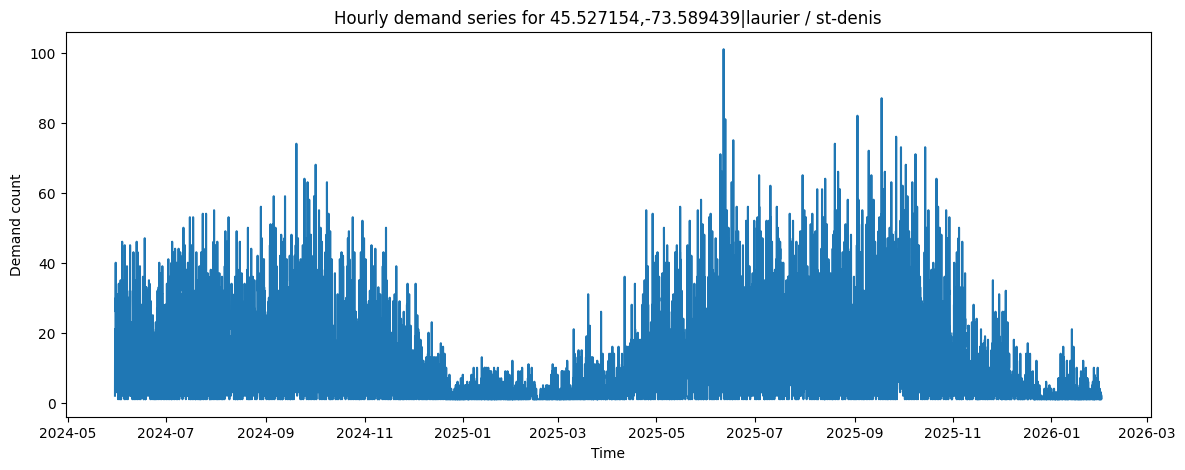

In [32]:
plt.figure(figsize=(14, 5))
plt.plot(station_pdf["ts_hour"], station_pdf["demand_count"])
plt.title(f"Hourly demand series for {TARGET_STATION}")
plt.xlabel("Time")
plt.ylabel("Demand count")
plt.show()

In [5]:
# Outflow series from the rides table for the target station
stn_df = rides_df.filter(F.col("start_canonical_station_id") == TARGET_STATION_ID)
hourly_df = (
    stn_df
    .withColumn("date", F.date_trunc("hour", "start_time_ms"))
    .groupBy("date")
    .agg(F.count("*").alias("outflow"))
    .orderBy("date")
)

display(hourly_df.limit(10)) if "display" in globals() else hourly_df.show(10, truncate=False)
print("Hourly rows for target station:", hourly_df.count())

+-------------------+-------+
|date               |outflow|
+-------------------+-------+
|2023-04-12 12:00:00|2      |
|2023-04-12 14:00:00|1      |
|2023-04-12 15:00:00|3      |
|2023-04-12 16:00:00|5      |
|2023-04-12 17:00:00|12     |
|2023-04-12 18:00:00|6      |
|2023-04-12 19:00:00|4      |
|2023-04-12 20:00:00|7      |
|2023-04-12 21:00:00|5      |
|2023-04-12 22:00:00|5      |
+-------------------+-------+
only showing top 10 rows


Hourly rows for target station: 20879


In [6]:
station_pdf = hourly_df.toPandas()
station_pdf["date"] = pd.to_datetime(station_pdf["date"])
station_pdf = station_pdf.sort_values("date").reset_index(drop=True)

station_pdf.head()

,date,outflow
0,2023-04-12 12:00:00,2
1,2023-04-12 14:00:00,1
2,2023-04-12 15:00:00,3
3,2023-04-12 16:00:00,5
4,2023-04-12 17:00:00,12


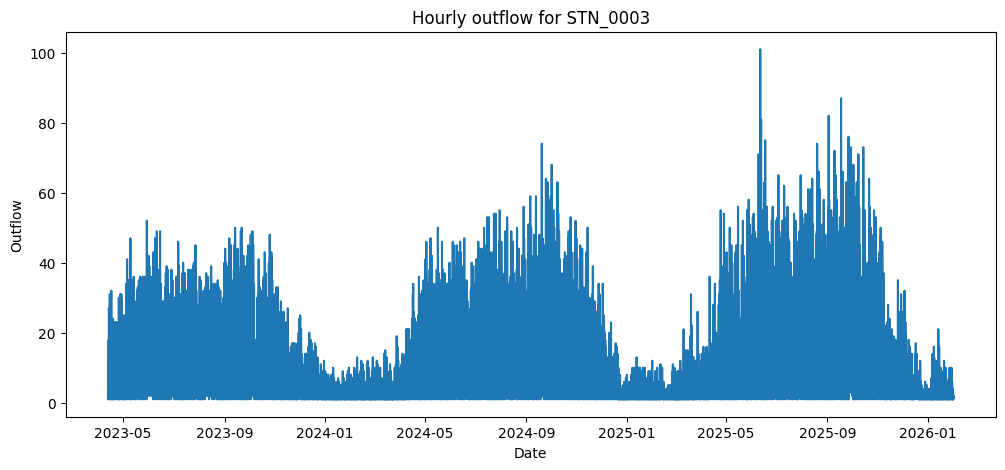

In [13]:
plt.plot(station_pdf["date"], station_pdf["outflow"])
plt.title(f"Hourly outflow for {TARGET_STATION_ID}")
plt.xlabel("Date")
plt.ylabel("Outflow")
plt.show()

## 4. Feature engineering for the station-level Prophet path

In [ ]:
# station_df = (
#     feature_ready_df
#     .filter(F.col("station_id") == TARGET_STATION)
#     .select(
#         "ts_hour",
#         "demand_count",
#         "temp",
#         "precip",
#         "is_weekend",
#         "is_holiday"
#     )
#     .orderBy("ts_hour")
# )

# print("Station row count:", station_df.count())
# station_df.show(5)

In [7]:
def build_station_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hour"] = df["date"].dt.hour
    df["day_of_week"] = df["date"].dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    for l in [1, 24, 168]:
        df[f"lag_{l}h"] = df["outflow"].shift(l)

    df["rolling_mean_3h"] = df["outflow"].rolling(window=3).mean().shift(1)
    return df

station_pdf_featured = build_station_time_features(station_pdf)
station_pdf_featured.head()

,date,outflow,hour,day_of_week,is_weekend,hour_sin,hour_cos,lag_1h,lag_24h,lag_168h,rolling_mean_3h
0,2023-04-12 12:00:00,2,12,2,0,1.224647e-16,-1.000000,NaN,NaN,NaN,NaN
1,2023-04-12 14:00:00,1,14,2,0,-5.000000e-01,-0.866025,2.0,NaN,NaN,NaN
2,2023-04-12 15:00:00,3,15,2,0,-7.071068e-01,-0.707107,1.0,NaN,NaN,NaN
3,2023-04-12 16:00:00,5,16,2,0,-8.660254e-01,-0.500000,3.0,NaN,NaN,2.0
4,2023-04-12 17:00:00,12,17,2,0,-9.659258e-01,-0.258819,5.0,NaN,NaN,3.0


## 5. Prepare a clean multi-station weather-aware panel

In [8]:
weather_panel_df = (
    incWeatherFeatures_df
    .select(
        "station_id",
        "ts_hour",
        "demand_count",
        "day_of_week",
        "is_weekend",
        "is_holiday",
        "temp",
        "precip",
        "lat",
        "lon",
        "dist_km",
        "metro_proximity",
        "metro_name",
        "transit_proximity_tier"
    )
)

# Fill numeric nulls; keep categoricals untouched for now
weather_panel_df = weather_panel_df.fillna({
    "temp": 0.0,
    "precip": 0.0,
    "lat": 0.0,
    "lon": 0.0,
    "dist_km": 0.0
})

weather_panel_df = weather_panel_df.filter(
    F.col("ts_hour").isNotNull() & F.col("demand_count").isNotNull()
)

weather_panel_df = (
    weather_panel_df
    .withColumn("hour_of_day", F.hour("ts_hour"))
    .withColumn("month", F.month("ts_hour"))
)

weather_panel_df.printSchema()
weather_panel_df.show(5, truncate=False)

root
 |-- station_id: string (nullable = true)
 |-- ts_hour: timestamp (nullable = true)
 |-- demand_count: long (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- temp: float (nullable = false)
 |-- precip: float (nullable = false)
 |-- lat: double (nullable = false)
 |-- lon: double (nullable = false)
 |-- dist_km: double (nullable = false)
 |-- metro_proximity: string (nullable = true)
 |-- metro_name: string (nullable = true)
 |-- transit_proximity_tier: string (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- month: integer (nullable = true)

+-----------------------------------------------------------+-------------------+------------+-----------+----------+----------+-----+------+---------+----------+-------------------+---------------+-------------+--------------------------+-----------+-----+
|station_id                                                 |ts_hour 

### Why this preparation is different from the previous attempt

The old notebook tried to model directly from `incWeatherFeatures_df` without separating:
- station-level time-series forecasting, and
- multi-station regression.

This rebuild keeps both paths, but uses each dataset at the correct grain.

## 6. Modeling Path A — Prophet for station-level hourly forecasting

In [14]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

def train_prophet_station_model(df: pd.DataFrame, horizon_hours: int = 24):
    prophet_df = df[["date", "outflow"]].rename(columns={"date": "ds", "outflow": "y"}).copy()
    prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])
    prophet_df = prophet_df.sort_values("ds").dropna()

    split_idx = int(len(prophet_df) * 0.8)
    train_pdf = prophet_df.iloc[:split_idx].copy()
    test_pdf = prophet_df.iloc[split_idx:].copy()

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True
    )
    model.fit(train_pdf)

    future = model.make_future_dataframe(periods=len(test_pdf) + horizon_hours, freq="H")
    forecast = model.predict(future)

    test_forecast = (
        forecast[["ds", "yhat"]]
        .merge(test_pdf, on="ds", how="inner")
        .rename(columns={"y": "actual"})
    )

    mae = mean_absolute_error(test_forecast["actual"], test_forecast["yhat"])
    rmse = mean_squared_error(test_forecast["actual"], test_forecast["yhat"])

    return model, forecast, test_forecast, {"mae": mae, "rmse": rmse}

prophet_model, prophet_forecast, prophet_test_forecast, prophet_metrics = train_prophet_station_model(station_pdf)

print("Prophet MAE :", round(prophet_metrics["mae"], 4))
print("Prophet RMSE:", round(prophet_metrics["rmse"], 4))
prophet_test_forecast.head()

10:28:41 - cmdstanpy - INFO - Chain [1] start processing
10:28:45 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE : 9.056
Prophet RMSE: 117.3556


,ds,yhat,actual
0,2025-07-07 21:00:00,19.347478,11
1,2025-07-07 22:00:00,17.196778,11
2,2025-07-07 23:00:00,16.194077,9
3,2025-07-08 00:00:00,15.298078,4
4,2025-07-08 01:00:00,13.474763,1


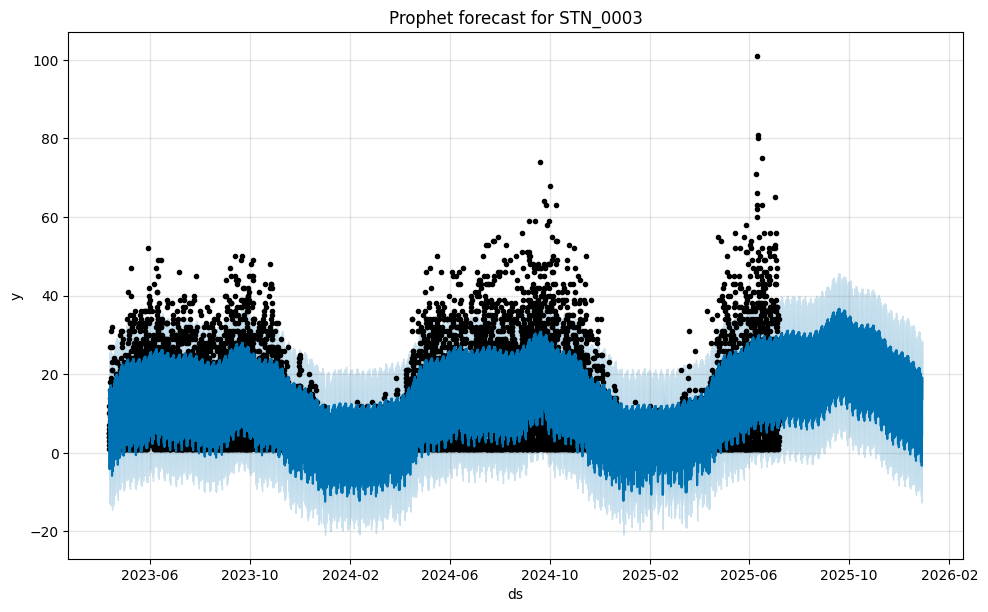

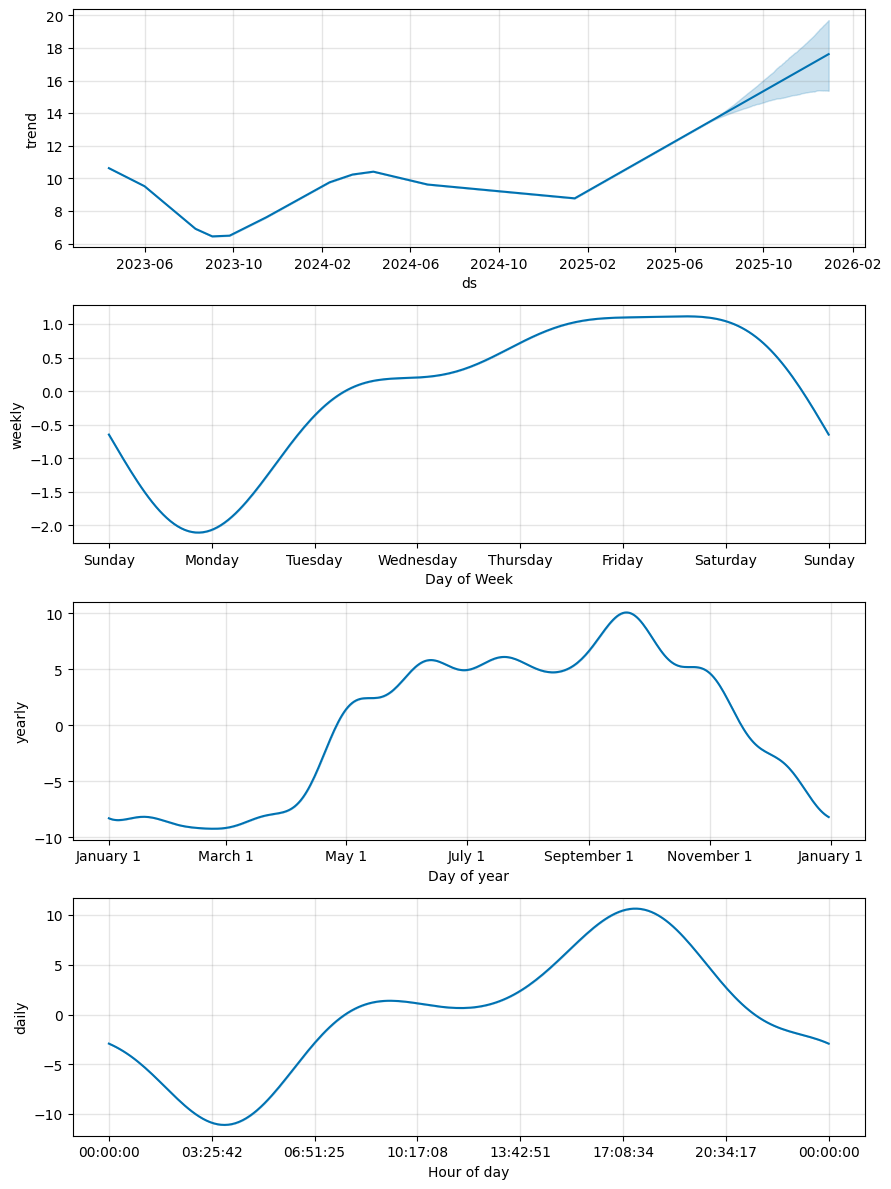

In [15]:
fig = prophet_model.plot(prophet_forecast)
plt.title(f"Prophet forecast for {TARGET_STATION_ID}")
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.show()

## 7. Modeling Path B — Spark ML baseline using weather and calendar features

This path uses the multi-station panel and gives a practical regression baseline.  
It does **not** use raw categorical strings inside the assembler.

In [9]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

numeric_feature_cols = [
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "hour_of_day",
    "month",
    "temp",
    "precip",
    "lat",
    "lon",
    "dist_km"
]

assembler = VectorAssembler(
    inputCols=numeric_feature_cols,
    outputCol="features"
)

weather_ml_df = (
    assembler
    .transform(weather_panel_df)
    .select("station_id", "ts_hour", "demand_count", "features")
)

display(weather_ml_df.limit(5)) if "display" in globals() else weather_ml_df.show(5, truncate=False)

+-----------------------------------------------------------+-------------------+------------+--------------------------------------------------------------------------------------+
|station_id                                                 |ts_hour            |demand_count|features                                                                              |
+-----------------------------------------------------------+-------------------+------------+--------------------------------------------------------------------------------------+
|45.524790,-73.565450|calixa-lavallée / sherbrooke          |2024-06-24 16:00:00|9           |[2.0,0.0,1.0,16.0,6.0,21.399999618530273,0.0,45.52479,-73.56545,0.7256533163973264]   |
|45.506539,-73.576609|university / milton                   |2024-10-19 18:00:00|18          |[7.0,1.0,0.0,18.0,10.0,13.899999618530273,0.0,45.506539,-73.576609,0.4817380565504807]|
|45.470400,-73.565519|métro lasalle (de rushbrooke / caisse)|2024-10-19 15:00:00|6        

In [11]:
# Time-based train/test split

# train set 2023, 2024
# test set 2025, 2026
train_cutoff = "2024-10-31"

train_df = weather_ml_df.filter(F.col("ts_hour") < F.lit(train_cutoff))
test_df = weather_ml_df.filter(F.col("ts_hour") >= F.lit(train_cutoff))

# have a small sample of the train and test sets for quick iteration during development
# train_small_df = train_df.sample(withReplacement=False, fraction=0.1, seed=42)
# test_small_df = test_df.sample(withReplacement=False, fraction=0.1, seed=42)

# even smaller sample with only features and target for super quick testing of modeling code
train_small_df = train_df.select("features", "demand_count").sample(False, 0.01, seed=42)
test_small_df  = test_df.select("features", "demand_count").sample(False, 0.01, seed=42)

print("Train rows:", train_df.count())
print("Test rows :", test_df.count())
print("Train sample rows:", train_small_df.count())
print("Test sample rows :", test_small_df.count())

Train rows: 2638412
Test rows : 3541203
Train sample rows: 26555
Test sample rows : 35499


In [14]:
train_small_df.show(5, truncate=False)

+-----------------------------------------------------------------------------------------------------+------------+
|features                                                                                             |demand_count|
+-----------------------------------------------------------------------------------------------------+------------+
|[4.0,0.0,0.0,20.0,7.0,23.049999237060547,0.0,45.547167,-73.618444,0.8605353415200776]                |10          |
|[2.0,0.0,0.0,16.0,3.0,4.650000095367432,0.10000000149011612,45.505173,-73.570652,0.13639170653121976]|4           |
|[3.0,0.0,0.0,10.0,7.0,25.5,0.0,45.534134,-73.573524,1.2478694558077998]                              |4           |
|[2.0,0.0,0.0,15.0,3.0,0.05000000074505806,0.0,45.502776,-73.575894,0.22841581295943203]              |4           |
|[6.0,0.0,0.0,23.0,5.0,8.649999618530273,0.0,45.569251,-73.636426,2.564642871100743]                  |1           |
+---------------------------------------------------------------

### running random forest on a small sample of the data

In [12]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark import StorageLevel


# Keep only required columns
train_rf = train_small_df.select("features", "demand_count").repartition(4)
test_rf  = test_small_df.select("features", "demand_count").repartition(4)

# Optional: persist to disk only, not memory
train_rf = train_rf.persist(StorageLevel.DISK_ONLY)
test_rf = test_rf.persist(StorageLevel.DISK_ONLY)

print("Train rows:", train_rf.count())
print("Test rows :", test_rf.count())

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="demand_count",
    predictionCol="prediction",
    numTrees=10,
    maxDepth=4,
    maxBins=32,
    subsamplingRate=0.6,
    seed=42
)

rf_model = rf.fit(train_rf)
rf_pred_df = rf_model.transform(test_rf)

rmse_eval = RegressionEvaluator(
    labelCol="demand_count",
    predictionCol="prediction",
    metricName="rmse"
)
mae_eval = RegressionEvaluator(
    labelCol="demand_count",
    predictionCol="prediction",
    metricName="mae"
)
r2_eval = RegressionEvaluator(
    labelCol="demand_count",
    predictionCol="prediction",
    metricName="r2"
)

rf_metrics = {
    "rmse": rmse_eval.evaluate(rf_pred_df),
    "mae": mae_eval.evaluate(rf_pred_df),
    "r2": r2_eval.evaluate(rf_pred_df),
}

rf_metrics

Train rows: 26555


Test rows : 35499


{'rmse': 4.422084268313848,
 'mae': 2.821450845007502,
 'r2': 0.17743291105332681}

##### use more data

In [15]:
# Time-based train/test split

# train set 2023, 2024
# test set 2025, 2026


train_small_df = train_df.sample(withReplacement=False, fraction=0.1, seed=42)
test_small_df = test_df.sample(withReplacement=False, fraction=0.1, seed=42)


print("Train rows:", train_df.count())
print("Test rows :", test_df.count())
print("Train sample rows:", train_small_df.count())
print("Test sample rows :", test_small_df.count())

Train rows: 2638412
Test rows : 3541203
Train sample rows: 263676
Test sample rows : 353935


In [17]:
train_rf = train_small_df.select("features", "demand_count").repartition(4)
test_rf  = test_small_df.select("features", "demand_count").repartition(4)

rf1 = RandomForestRegressor(
    featuresCol="features",
    labelCol="demand_count",
    predictionCol="prediction",
    numTrees=10,
    maxDepth=4,
    maxBins=32,
    subsamplingRate=0.6,
    seed=42
)

rf1_model = rf1.fit(train_rf)
rf1_pred_df = rf1_model.transform(test_rf)

rmse_eval1 = RegressionEvaluator(
    labelCol="demand_count",
    predictionCol="prediction",
    metricName="rmse"
)
mae_eval1 = RegressionEvaluator(
    labelCol="demand_count",
    predictionCol="prediction",
    metricName="mae"
)
r2_eval1 = RegressionEvaluator(
    labelCol="demand_count",
    predictionCol="prediction",
    metricName="r2"
)

rf1_metrics = {
    "rmse": rmse_eval1.evaluate(rf1_pred_df),
    "mae": mae_eval1.evaluate(rf1_pred_df),
    "r2": r2_eval1.evaluate(rf1_pred_df),
}

rf1_metrics

{'rmse': 4.501384979180148,
 'mae': 2.8398506742508713,
 'r2': 0.17232526502065149}

In [18]:
feature_importance_pdf = pd.DataFrame({
    "feature": numeric_feature_cols,
    "importance": rf_model.featureImportances.toArray()
}).sort_values("importance", ascending=False)

feature_importance_pdf

,feature,importance
5,temp,0.306530
3,hour_of_day,0.209613
7,lat,0.203090
8,lon,0.193481
9,dist_km,0.048440
4,month,0.032147
6,precip,0.002361
1,is_weekend,0.002360
0,day_of_week,0.001977
2,is_holiday,0.000000


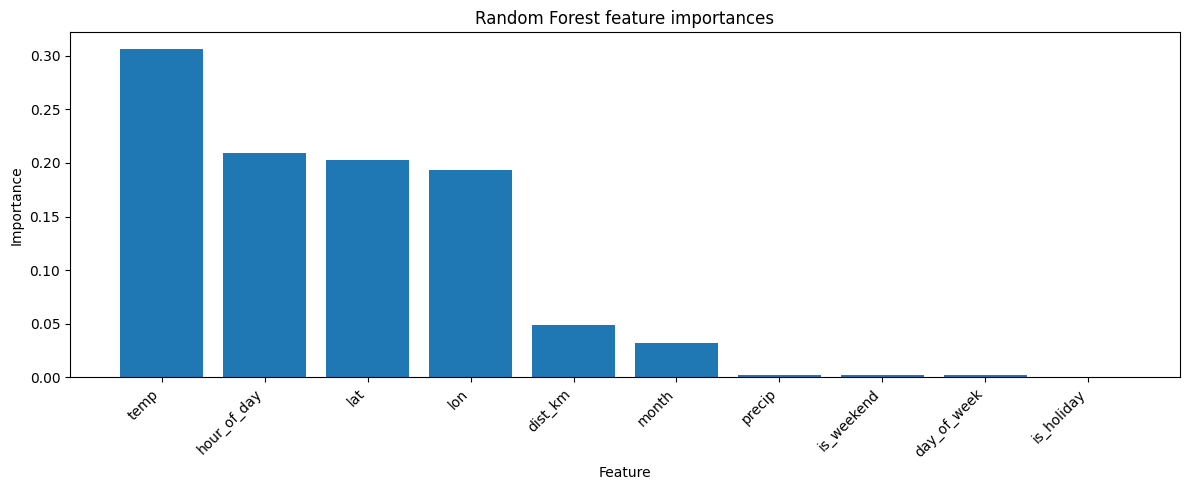

In [19]:
plt.bar(feature_importance_pdf["feature"], feature_importance_pdf["importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Random Forest feature importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## 8. Optional extension — encode categorical station context for a richer Spark pipeline

In [20]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder

categorical_cols = ["metro_proximity", "metro_name", "transit_proximity_tier"]

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
    for c in categorical_cols
]

full_feature_cols = numeric_feature_cols + [f"{c}_ohe" for c in categorical_cols]

# This is a template block for a more advanced pipeline.
# Keep it optional because the numeric-only baseline is easier to debug first.
pipeline_stages = indexers + encoders
pipeline = Pipeline(stages=pipeline_stages)

encoded_model = pipeline.fit(weather_panel_df)
encoded_df = encoded_model.transform(weather_panel_df)

encoded_df.select(
    "station_id", "ts_hour", "demand_count",
    *[f"{c}_idx" for c in categorical_cols],
    *[f"{c}_ohe" for c in categorical_cols]
).show(5, truncate=False)

+-----------------------------------------------------------+-------------------+------------+-------------------+--------------+--------------------------+-------------------+---------------+--------------------------+
|station_id                                                 |ts_hour            |demand_count|metro_proximity_idx|metro_name_idx|transit_proximity_tier_idx|metro_proximity_ohe|metro_name_ohe |transit_proximity_tier_ohe|
+-----------------------------------------------------------+-------------------+------------+-------------------+--------------+--------------------------+-------------------+---------------+--------------------------+
|45.524790,-73.565450|calixa-lavallée / sherbrooke          |2024-06-24 16:00:00|9           |0.0                |2.0           |0.0                       |(3,[0],[1.0])      |(68,[2],[1.0]) |(3,[0],[1.0])             |
|45.506539,-73.576609|university / milton                   |2024-10-19 18:00:00|18          |0.0                |19.0  

## 8. Modeling Path C — Station-specific Spark ML models for STN_0003

This path narrows the data down to **STN_0003 only** and compares three Spark ML regressors:
- **Random Forest** as a stronger non-linear tree baseline
- **Gradient-Boosted Trees** for a more sequential boosting-based fit
- **Linear Regression** as a simple Spark ML benchmark

The goal here is to see whether a **single-station supervised learning setup** performs better than the earlier multi-station panel baseline.


In [24]:
weather_ml_df.show(5, truncate=False)

+-----------------------------------------------------------+-------------------+------------+--------------------------------------------------------------------------------------+
|station_id                                                 |ts_hour            |demand_count|features                                                                              |
+-----------------------------------------------------------+-------------------+------------+--------------------------------------------------------------------------------------+
|45.524790,-73.565450|calixa-lavallée / sherbrooke          |2024-06-24 16:00:00|9           |[2.0,0.0,1.0,16.0,6.0,21.399999618530273,0.0,45.52479,-73.56545,0.7256533163973264]   |
|45.506539,-73.576609|university / milton                   |2024-10-19 18:00:00|18          |[7.0,1.0,0.0,18.0,10.0,13.899999618530273,0.0,45.506539,-73.576609,0.4817380565504807]|
|45.470400,-73.565519|métro lasalle (de rushbrooke / caisse)|2024-10-19 15:00:00|6        

In [23]:
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor, LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark import StorageLevel

TARGET_STATION_PATH_C = "STN_0003"

station_weather_df = (
    weather_ml_df
    .filter(F.col("station_id") == TARGET_STATION_PATH_C)
)

station_weather_ml_df = (
    assembler
    .transform(station_weather_df)
    .select("station_id", "ts_hour", "demand_count", *numeric_feature_cols, "features")
)

print("Station rows for path C:", station_weather_ml_df.count())
display(station_weather_ml_df.limit(5)) if "display" in globals() else station_weather_ml_df.show(5, truncate=False)


IllegalArgumentException: [FIELD_NOT_FOUND] No such struct field `day_of_week` in `station_id`, `ts_hour`, `demand_count`, `features`. SQLSTATE: 42704